In [2]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [3]:
import pickle
import torch

In [4]:
from src.models.bilstm_attention import BiLSTMAttention
from src.data.dataset import NextWordDataset
from torch.utils.data import DataLoader

In [5]:
with open("../data/processed/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("../data/processed/X.pkl", "rb") as f:
    X = pickle.load(f)

with open("../data/processed/y.pkl", "rb") as f:
    y = pickle.load(f)

In [6]:
dataset = NextWordDataset(X, y)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [7]:
model = BiLSTMAttention(
    vocab_size=len(vocab.word_to_idx)
)

print(model)

BiLSTMAttention(
  (embedding): Embedding(39275, 256)
  (bilstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=512, out_features=1, bias=True)
  )
  (fc): Linear(in_features=512, out_features=39275, bias=True)
)


In [8]:
sample_x, sample_y = next(
    iter(train_loader)
)

output = model(sample_x)

print(output.shape)

torch.Size([64, 39275])


In [9]:
from src.training.trainer import Trainer

In [10]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [11]:
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    learning_rate=0.001,
    device=device
)

In [12]:
num_epochs = 20

losses = []

for epoch in range(num_epochs):

    loss = trainer.train_one_epoch()

    losses.append(loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {loss:.4f}"
    )

Training: 100%|██████████| 3125/3125 [12:38<00:00,  4.12it/s, loss=5.37]


Epoch [1/20] Loss: 6.4220


Training: 100%|██████████| 3125/3125 [10:03<00:00,  5.18it/s, loss=4.81]


Epoch [2/20] Loss: 5.4351


Training: 100%|██████████| 3125/3125 [13:31<00:00,  3.85it/s, loss=5.48]


...

Epoch [18/20] Loss: 1.2425


Training: 100%|██████████| 3125/3125 [09:30<00:00,  5.48it/s, loss=1.21] 


Epoch [19/20] Loss: 1.1880


Training: 100%|██████████| 3125/3125 [13:54<00:00,  3.74it/s, loss=1.53] 

Epoch [20/20] Loss: 1.1369


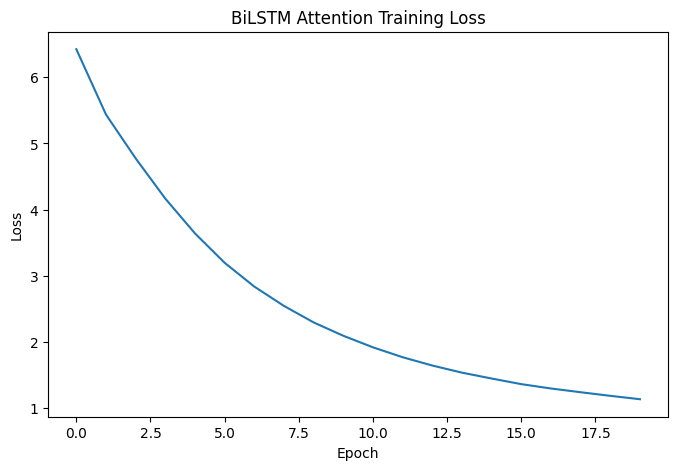

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Attention Training Loss")

plt.show()

In [14]:
import os
import torch

os.makedirs("../artifacts/model", exist_ok=True)

torch.save(
    model.state_dict(),
    "../artifacts/model/bilstm_attention_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [15]:
import pickle
import os

os.makedirs("../artifacts/vocab", exist_ok=True)

with open(
    "../artifacts/vocab/vocab.pkl",
    "wb"
) as f:

    pickle.dump(vocab, f)

print("Vocabulary Saved Successfully")

Vocabulary Saved Successfully


In [16]:
import os

model_size = (
    os.path.getsize(
        "../artifacts/model/bilstm_attention_model.pth"
    ) / 1024 / 1024
)

vocab_size = (
    os.path.getsize(
        "../artifacts/vocab/vocab.pkl"
    ) / 1024 / 1024
)

print(f"Model Size : {model_size:.2f} MB")
print(f"Vocab Size : {vocab_size:.2f} MB")

Model Size : 125.25 MB
Vocab Size : 0.79 MB
